In [1]:
import pandas as pd
import numpy as num_paths
import matplotlib.pyplot as psnrResault
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt

import pickle

/home/gurhancoban/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df=pd.read_csv("data21.11.2024.csv")

In [3]:
df=pd.DataFrame(df)
df.head()

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server,tahmin_mos,real_mos
0,h7,258.305,0.0,64,3,10000000,32.497785,0.987272,18.952240,67209812,...,9746,1041430,1051176,9774,1046860,1056634,6,h14,0,4
1,h8,221.283,0.0,40,2,10000000,25.858796,0.963395,14.364558,67209812,...,10698,1047640,2109514,1917520,1058092,4032246,6,h14,[4.30576841],4
2,h9,280.149,0.0,62,3,10000000,21.589305,0.918842,10.906686,67209812,...,11664,1055366,3176544,5922754,1077567,11032567,6,h14,[4.01532466],3
3,h11,215.956,0.0,45,2,10000000,36.507699,0.996039,24.022245,67209812,...,12630,1066302,4255476,11962986,1106125,24101678,6,h10,[3.97113222],5
4,h12,331.428,0.0,65,3,10000000,34.859543,0.994015,22.229087,67209812,...,1420026,1083418,6758920,18242840,1136073,43480591,6,h10,[3.89867304],5


In [4]:
df["mos"]=6
df.shape[0]
for i in range(0,df.shape[0],1):
    if df.ssim_first[i]>=0.99:
        df.mos[i]=5
    elif df.ssim_first[i]>=0.95 and df.ssim_first[i]<0.99:
        df.mos[i]=4
    elif df.ssim_first[i]>=0.88 and df.ssim_first[i]<0.95:
        df.mos[i]=3
    elif df.ssim_first[i]>=0.5 and df.ssim_first[i]<0.88:
        df.mos[i]=2
    elif df.ssim_first[i]<0.5:
        df.mos[i]=1

df

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server,tahmin_mos,real_mos,mos
0,h7,258.305,0.0,64,3,10000000,32.497785,0.987272,18.952240,67209812,...,1041430,1051176,9774,1046860,1056634,6,h14,0,4,4
1,h8,221.283,0.0,40,2,10000000,25.858796,0.963395,14.364558,67209812,...,1047640,2109514,1917520,1058092,4032246,6,h14,[4.30576841],4,4
2,h9,280.149,0.0,62,3,10000000,21.589305,0.918842,10.906686,67209812,...,1055366,3176544,5922754,1077567,11032567,6,h14,[4.01532466],3,3
3,h11,215.956,0.0,45,2,10000000,36.507699,0.996039,24.022245,67209812,...,1066302,4255476,11962986,1106125,24101678,6,h10,[3.97113222],5,5
4,h12,331.428,0.0,65,3,10000000,34.859543,0.994015,22.229087,67209812,...,1083418,6758920,18242840,1136073,43480591,6,h10,[3.89867304],5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,h1,964.346,0.0,63,3,10000000,17.621621,0.842519,8.027728,67209812,...,25481861,382949415,40935832,25882479,257913566,6,h14,[3.18639166],2,2
191,h2,885.964,0.0,68,3,10000000,18.302378,0.856217,8.422921,67209812,...,38919502,502339807,53345952,39537363,350796881,6,h14,[2.91905114],2,2
192,h3,732.694,0.0,42,2,10000000,25.686286,0.965367,14.605127,67209812,...,56965521,650253394,67765342,57814537,476376760,6,h14,[2.46776845],4,4
193,h4,254.412,0.0,79,3,10000000,22.383904,0.881869,9.276355,67209812,...,79721802,831348048,84314296,80922883,641613939,6,h10,[2.27649564],3,3


In [5]:
df.dropna(inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,195.0,6.947314e+02,4.176305e+02,1.532680e+02,2.942530e+02,5.688720e+02,1.135694e+03,1.438583e+03
packetLoss,195.0,3.418803e-01,3.551059e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.444444e+01
latency,195.0,7.240000e+01,2.644161e+01,1.400000e+01,5.100000e+01,7.000000e+01,8.550000e+01,1.510000e+02
hopCount,195.0,2.682051e+00,7.539832e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00
bandwidth,195.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
psnr,195.0,2.370230e+01,6.079004e+00,1.579758e+01,1.863203e+01,2.201557e+01,2.669195e+01,3.796985e+01
ssim_first,195.0,9.115721e-01,7.088114e-02,6.762290e-01,8.611455e-01,9.272810e-01,9.718575e-01,9.974720e-01
ssim_second,195.0,1.268465e+01,5.092188e+00,4.897626e+00,8.574400e+00,1.138354e+01,1.550804e+01,2.597268e+01
kaynak,195.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,195.0,5.944888e+07,6.948881e+06,4.037018e+07,5.387059e+07,6.029312e+07,6.632243e+07,6.737101e+07


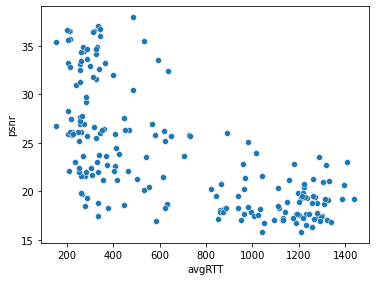

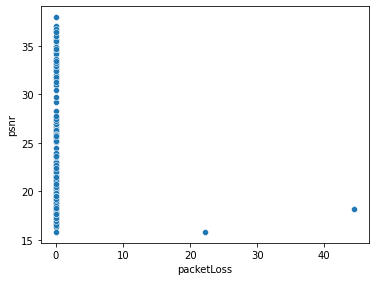

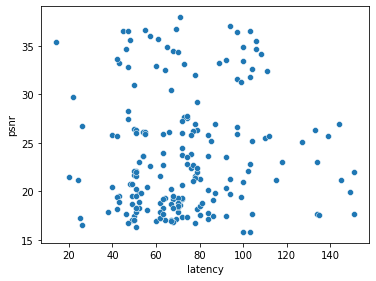

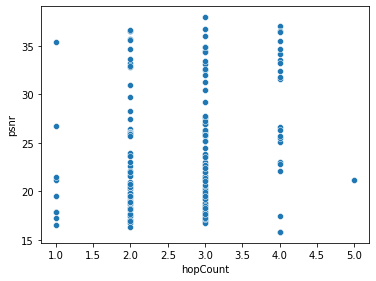

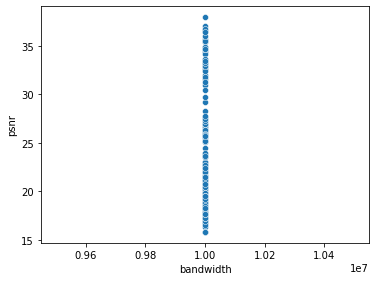

In [6]:
sayisal_veriler=["avgRTT","packetLoss","latency","hopCount","bandwidth"]
for i,deger in enumerate(sayisal_veriler):
    plt.figure(figsize=(20,20))
    ax=plt.subplot(4,3,i+1)
    sns.scatterplot(x=deger,y="psnr",data=df)
    plt.show()

In [7]:
# sns.displot(df)

In [8]:
df["mos"].value_counts()

mos
2    69
4    56
3    46
5    24
Name: count, dtype: int64

In [11]:
y=df["mos"]
x=df.drop(["mos","host","ssim_first","ssim_second","type","psnr","server","packetLoss","kaynak","kayitboyut","kayip","kayip_orani","tahmin_mos","real_mos"],axis="columns")
y


0      4
1      4
2      3
3      5
4      5
      ..
190    2
191    2
192    4
193    3
194    3
Name: mos, Length: 195, dtype: int64

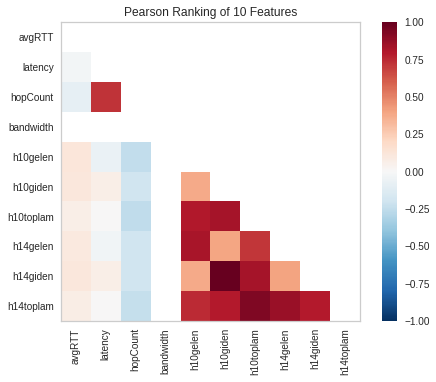

<AxesSubplot:title={'center':'Pearson Ranking of 10 Features'}>

In [12]:
from yellowbrick.features import Rank2D
visualizer=Rank2D(algorithm="pearson")
visualizer.fit(x,y)
visualizer.transform(x)
visualizer.show()

In [13]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,195.0,6.947314e+02,4.176305e+02,1.532680e+02,2.942530e+02,5.688720e+02,1.135694e+03,1.438583e+03
latency,195.0,7.240000e+01,2.644161e+01,1.400000e+01,5.100000e+01,7.000000e+01,8.550000e+01,1.510000e+02
hopCount,195.0,2.682051e+00,7.539832e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,5.000000e+00
bandwidth,195.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
h10gelen,195.0,3.019760e+07,2.919340e+07,9.446000e+03,4.284931e+06,2.248929e+07,4.936490e+07,1.132678e+08
h10giden,195.0,1.559787e+07,4.426205e+07,8.405900e+04,6.054770e+05,1.598844e+06,3.514466e+06,3.180553e+08
h10toplam,195.0,1.806616e+08,2.635111e+08,9.370700e+04,9.176682e+06,8.035992e+07,2.624345e+08,1.882862e+09
h14gelen,195.0,4.528228e+07,4.249590e+07,9.368000e+03,1.009279e+07,3.268447e+07,7.521490e+07,1.624173e+08
h14giden,195.0,1.582500e+07,4.483276e+07,9.341900e+04,5.978345e+05,1.488636e+06,3.189907e+06,3.206839e+08
h14toplam,195.0,2.461526e+08,3.235023e+08,1.029830e+05,2.232612e+07,1.153775e+08,3.624992e+08,2.022866e+09


In [14]:
from sklearn.model_selection import train_test_split
XTrain,XTest,yTrain,yTest=train_test_split(x,y,test_size=0.10, random_state=42)

In [15]:
yTest.value_counts()

mos
4    9
2    8
3    2
5    1
Name: count, dtype: int64

In [16]:
from sklearn.linear_model import LinearRegression
LinModel=LinearRegression()
LinModel.fit(XTrain,yTrain)
tahmin=LinModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

0.4976421566258752


In [17]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.5569155858471482 test: 0.22514814997114985
max_depth : 2 --> score r2 : eğitim:0.708759371400378 test: 0.4783078027986939
max_depth : 3 --> score r2 : eğitim:0.7815927749802347 test: 0.5531926331524268
max_depth : 4 --> score r2 : eğitim:0.836330740987197 test: 0.5518943853098937
max_depth : 5 --> score r2 : eğitim:0.8839497389541535 test: 0.5385593269934101
max_depth : 6 --> score r2 : eğitim:0.9190457336786134 test: 0.5130710678258461
max_depth : 7 --> score r2 : eğitim:0.9322468292947654 test: 0.5643593902204544
max_depth : 8 --> score r2 : eğitim:0.9430330973367106 test: 0.539754702458867
max_depth : 9 --> score r2 : eğitim:0.9517419782514984 test: 0.576692366178009
max_depth : 10 --> score r2 : eğitim:0.9459217251664915 test: 0.5599483071357223
max_depth : 11 --> score r2 : eğitim:0.9511814433834204 test: 0.5738279656416216
max_depth : 12 --> score r2 : eğitim:0.9522754104204275 test: 0.519450072992701
max_depth : 13 --> score r2 : eğitim:0.94

In [18]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: -0.07055961070559591
n_neigbors : 2 --> score r2 : eğitim:0.6703555450906522 test: 0.36739659367396604
n_neigbors : 3 --> score r2 : eğitim:0.5988181199801166 test: 0.47012706136793725
n_neigbors : 4 --> score r2 : eğitim:0.568951244996468 test: 0.5407542579075426
n_neigbors : 5 --> score r2 : eğitim:0.5481810689898752 test: 0.5425790754257908
n_neigbors : 6 --> score r2 : eğitim:0.54316200324412 test: 0.5174371451743716
n_neigbors : 7 --> score r2 : eğitim:0.5068998284503347 test: 0.5640299915586673
n_neigbors : 8 --> score r2 : eğitim:0.4799408038026842 test: 0.6183090024330902
n_neigbors : 9 --> score r2 : eğitim:0.48302287453452986 test: 0.6365384037727915
n_neigbors : 10 --> score r2 : eğitim:0.48446697668942784 test: 0.6340632603406327
n_neigbors : 11 --> score r2 : eğitim:0.472671034682722 test: 0.6412700327763368
n_neigbors : 12 --> score r2 : eğitim:0.46765425103994973 test: 0.6316572046499054
n_neigbors : 13 --> score r2 : eğitim

In [19]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.538999217217347 test: 0.18167281248276568
max_depth : 2 --> score r2 : eğitim:0.6776759258143229 test: 0.38045932231888
max_depth : 3 --> score r2 : eğitim:0.7529383486382544 test: 0.30198702351987017
max_depth : 4 --> score r2 : eğitim:0.8105606673603201 test: 0.3923741642367463
max_depth : 5 --> score r2 : eğitim:0.8490721927312981 test: 0.3191528526357933
max_depth : 6 --> score r2 : eğitim:0.9027564855063923 test: 0.2709266013229077
max_depth : 7 --> score r2 : eğitim:0.9575825149932825 test: 0.25182481751824837
max_depth : 8 --> score r2 : eğitim:0.9744917981320147 test: 0.28819703063707247
max_depth : 9 --> score r2 : eğitim:0.9848990998993942 test: 0.36739659367396604
max_depth : 10 --> score r2 : eğitim:0.9920593458127306 test: 0.4160583941605841
max_depth : 11 --> score r2 : eğitim:1.0 test: 0.2214111922141121
max_depth : 12 --> score r2 : eğitim:1.0 test: 0.17274939172749404
max_depth : 13 --> score r2 : eğitim:1.0 test: 0.221411192214112

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.7792359063571216 test: 0.5471778752313479
max_depth : 2 --> score r2 : eğitim:0.8971833902711376 test: 0.5681475851912138
max_depth : 3 --> score r2 : eğitim:0.9725456369500224 test: 0.5410365424529125
max_depth : 4 --> score r2 : eğitim:0.9948954533297457 test: 0.5254063805279656
max_depth : 5 --> score r2 : eğitim:0.9995460326164645 test: 0.5991330885994812
max_depth : 6 --> score r2 : eğitim:0.9999603784275192 test: 0.547141871841905
max_depth : 7 --> score r2 : eğitim:0.9999981491488541 test: 0.4930914566390948
max_depth : 8 --> score r2 : eğitim:0.9999999368927837 test: 0.4100237091337555
max_depth : 9 --> score r2 : eğitim:0.9999999949292314 test: 0.516987455411463


In [21]:
from xgboost import XGBRegressor
xgb=XGBRegressor()
xgb.fit(XTrain,yTrain)
tahminXGB=xgb.predict(XTest)
print(r2_score(yTest,tahminXGB))

0.5590734294138668


In [22]:
from sklearn.linear_model import RANSACRegressor
ransac=RandomForestRegressor(random_state=42)
ransac.fit(XTrain,yTrain)
tahminRansac=ransac.predict(XTest)
print(f"ransac -> {r2_score(yTest,tahminRansac)}")

ransac -> 0.5424038929440389


In [29]:
from sklearn.ensemble import ExtraTreesRegressor
for i in range(1,10,1):
    exTree=ExtraTreesRegressor(max_depth=i)
    exTree.fit(XTrain,yTrain)
    tahminExTree=exTree.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminExTree)}")

    model_pkl_file=f"extraTreeRegressor{i}.pkl"

    with open(model_pkl_file,'wb') as file:
        pickle.dump(model,file)

max_depth : 1 --> score r2 : eğitim:0.46019318756456196 test: 0.4977494180342533
max_depth : 2 --> score r2 : eğitim:0.6342437144591708 test: 0.6787326687590536
max_depth : 3 --> score r2 : eğitim:0.708906104706585 test: 0.7630195037183161
max_depth : 4 --> score r2 : eğitim:0.7586882915811424 test: 0.798104973856921
max_depth : 5 --> score r2 : eğitim:0.8066897242740976 test: 0.8143317105472513
max_depth : 6 --> score r2 : eğitim:0.8543450626694719 test: 0.8276930522580755
max_depth : 7 --> score r2 : eğitim:0.8956968939163157 test: 0.8304136711263551
max_depth : 8 --> score r2 : eğitim:0.9369628966910901 test: 0.8352953857734748
max_depth : 9 --> score r2 : eğitim:0.9594800713482318 test: 0.8442595934454109


In [23]:
model=ExtraTreesRegressor(max_depth=7)
model.fit(XTrain,yTrain)
model_pkl_file="extraTreeRegressor.pkl"

with open(model_pkl_file,'wb') as file:
    pickle.dump(model,file)

NameError: name 'ExtraTreesRegressor' is not defined

In [24]:
tahminModel=model.predict(XTest)
print(f"max_depth : {7} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminModel)}")

NameError: name 'model' is not defined

In [30]:
tahminModel

array([2.01739659, 2.0012492 , 2.49251701, 3.20861354, 3.78041013,
       3.57785471, 2.07904362, 3.35094331, 4.47123824, 3.87430315,
       4.02565654, 3.33928884, 3.97134777, 2.182441  , 2.05562965,
       2.44551569, 4.07616865, 2.09218329, 4.31477583, 2.25724273,
       3.14888233, 3.59662965, 3.86699021, 2.02299076, 2.31829595,
       3.56743105, 3.57841984, 2.11469036, 2.00043723, 3.91380324,
       2.89949053, 2.99425313, 2.04373882, 2.00446965, 3.46232976,
       2.00043723, 2.15948487, 3.43608468, 2.00297931, 2.23666145,
       2.06498223, 3.31493322, 4.10583084, 3.55288056, 3.88345205,
       3.93601186, 3.82410731, 2.23010196, 2.31199725, 3.86231762,
       4.43086643, 2.66756034, 4.18709621, 2.04791983, 2.00170374,
       2.93629744, 3.98111362, 3.85382499, 2.17651944])

In [22]:
tahminGbr

array([2.00005305, 2.00004194, 2.000069  , 2.99217945, 3.92989164,
       3.63271253, 2.00004554, 3.34310607, 3.87907183, 3.93495963,
       3.86075751, 3.99903705, 3.999522  , 2.00002238, 2.00004552,
       1.99817866, 4.22622588, 2.00004479, 3.86114631, 2.00014202,
       2.78804528, 3.35369772, 4.00353725, 2.00004552, 2.00048913,
       3.07467731, 3.50821419, 2.00004579, 2.00004194, 4.03963844,
       2.99980735, 3.95384645, 2.00004579, 2.00004196, 3.99859104,
       2.00004552, 2.00006721, 3.09827549, 2.00004552, 2.13135353,
       2.000041  , 3.15477885, 4.09716166, 3.99900706, 3.95952435,
       3.96007127, 3.82177817, 2.00002901, 2.00020548, 3.97671998,
       4.66748364, 2.9519213 , 3.99712628, 2.00004554, 2.00004194,
       2.99998112, 3.98401837, 3.59781216, 2.07983832])

In [23]:
yTest

525    2
286    2
517    2
333    3
211    4
90     4
301    2
181    4
549    4
137    4
550    4
70     4
397    4
236    2
425    2
155    3
210    4
373    2
506    5
182    3
282    3
229    4
2      5
563    2
200    2
63     4
55     4
588    2
288    2
29     4
477    2
233    2
589    2
251    2
82     4
322    2
283    2
176    3
456    2
555    2
250    2
212    3
177    5
10     4
429    4
529    4
6      4
492    2
351    2
279    3
145    5
554    3
72     4
454    2
252    2
426    3
101    4
86     4
382    3
Name: mos, dtype: int64

In [24]:
yTrain

318    2
76     4
532    3
573    4
30     4
      ..
71     3
106    4
272    2
438    2
102    4
Name: mos, Length: 529, dtype: int64

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
XTrain[sayisal_veriler]=scaler.fit_transform(XTrain[sayisal_veriler])
XTest[sayisal_veriler]=scaler.transform(XTest[sayisal_veriler])

KeyError: "['packetLoss'] not in index"

In [ ]:
from sklearn.linear_model import LinearRegression
LogModel=LinearRegression()
LogModel.fit(XTrain,yTrain)
tahmin=LogModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,bootstrap=True,criterion="friedman_mse",max_features='log2',max_leaf_nodes=None,n_estimators=100,n_jobs=1,random_state=42)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

In [ ]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")